# Generate Plots of Absolute Geostrophic Velocity in transects of the Beaufort Gyre

### Configure the notebook and load necessary packages

In [1]:
#Jupyter Notebook config
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [23]:
from functools import reduce

#Load necessary python packages
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.colors import Normalize
import seaborn as sns
import cartopy.crs as ccrs
from cmocean import cm
import numpy as np
import xarray as xr
import gsw
from scipy.spatial import cKDTree
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from skimage import measure

from ipywidgets import widgets
from IPython.display import display

#Import custom package for working with Beaufort Gyre data
from datatools import io
import datatools.ctd.operations as dsops
import datatools.plots.maps as mapper
import datatools.plots.section as sectionPlotter
import datatools.plots.TwoD as twoDPlotter
import ocean_tools as fod
from datatools.DOT.DataServer import DataServer

In [3]:
#Define if processing should be done from scratch or preload CTD transects
process_from_scratch = False

### Extract the CTD Transects from the full dataset
* Read in the data
* Extract each transect
* Plot the transects on a map

In [4]:
#Read raw CTD data
ds = io.readers.readLSSL("/Users/ben/Desktop/3D-TEA-BAG/data/BGOS_shipboard_03_25.nc")

if process_from_scratch:
    #Slice the data to extract each transect
    #Eastern N-S transect (IVO 140˚W)
    e_ns_transect = dsops.var_slice(ds, 'lon', -140.5, -139.5)

    #Westren N-S transect (IVO 150˚W)
    w_ns_transect = dsops.var_slice(ds, 'lon', w_ns_main_slice_start := -150.75, -149.25)
    #Also capture small "dogleg" at the southren end of the transect
    w_ns_dogleg = dsops.var_slice(ds, 'lat', 70,72) #Latitude slice
    w_ns_dogleg = dsops.var_slice(w_ns_dogleg, 'lon', -153, w_ns_main_slice_start) #Longitude Slice
    #Combine datasets
    w_ns_transect = reduce(lambda a, b: a.combine_first(b), [w_ns_transect, w_ns_dogleg])

    #Northren E-W transect (IVO 75˚-78˚N)
    n_ew_transect = dsops.var_slice_line(ds,
                                        lat1 = 78.1,
                                        lon1 = -154.4,
                                        lat2 = 75.5,
                                        lon2 = -128.7,
                                        tolerance=25)
    #Get clump of stations at the northren end of the transect
    n_ew_n_clump = dsops.var_slice(ds, 'lat', 78.2,78.4) #Latitude slice
    n_ew_n_clump = dsops.var_slice(n_ew_n_clump, 'lon', -155, -152) #Longitude Slice

    #Get dogleg at the southren end of the transect
    n_ew_s_dogleg = dsops.var_slice(ds, 'lat', 75.7,75.9) #Latitude slice
    n_ew_s_dogleg = dsops.var_slice(n_ew_s_dogleg, 'lon', -129, -127) #Longitude Slice

    #Combine datasets
    n_ew_transect = reduce(lambda a, b: a.combine_first(b), [n_ew_transect, n_ew_n_clump, n_ew_s_dogleg])

    #Southren E-W transect (IVO 71˚-76˚N)
    #Northren leg from 160˚W to 150˚W
    s_ew_n_leg = dsops.var_slice_line(ds,
                                    lat1 = 76,
                                    lon1 = -160,
                                    lat2 = 75,
                                    lon2 = -150,
                                    tolerance= 35)

    #Cut off random points caught up by the extention of the line past the 150˚-160˚W, 75-76˚N box
    s_ew_n_leg = dsops.var_slice(s_ew_n_leg, 'lat', 75,76) #Latitude slice
    s_ew_n_leg = dsops.var_slice(s_ew_n_leg, 'lon', -160, -150) #Longitude Slice


    #Middle leg from 150˚W to 140˚W
    s_ew_m_leg = dsops.var_slice_line(ds,
                                    lat1 = 75,
                                    lon1 = -150,
                                    lat2 = 74,
                                    lon2 = -140,
                                    tolerance= 35)
    #Cut off random points caught up by the extention of the line past the 140˚-150˚W, 74-75˚N box
    s_ew_m_leg = dsops.var_slice(s_ew_m_leg, 'lat', 74,75) #Latitude slice
    s_ew_m_leg = dsops.var_slice(s_ew_m_leg, 'lon', -150, -140) #Longitude Slice

    #Southren leg from 140˚W to 129˚W
    s_ew_s_leg = dsops.var_slice_line(ds,
                                    lat1 = 74,
                                    lon1 = -140,
                                    lat2 = 71,
                                    lon2 = -129,
                                    tolerance=40)
    #Cut off random points caught up by the extention of the line past the 129˚-140˚W, 71-74˚N box
    s_ew_s_leg = dsops.var_slice(s_ew_s_leg, 'lat', 71,74) #Latitude slice
    s_ew_s_leg = dsops.var_slice(s_ew_s_leg, 'lon', -140, -129) #Longitude Slice

    #Grab a few stragglers at the northren terminus
    s_ew_n_clump = dsops.var_slice(ds, 'lat', 75.9, 76.1) #Latitude slice
    s_ew_n_clump = dsops.var_slice(s_ew_n_clump, 'lon', -161, -159) #Longitude Slice

    #Grab a few stragglers IVO 150˚W 75N
    s_ew_m_clump = dsops.var_slice(ds, 'lat', 74.8, 75.2) #Latitude slice
    s_ew_m_clump = dsops.var_slice(s_ew_m_clump, 'lon', -150.2, -149.8) #Longitude Slice

    #Grab a few stragglers IVO 140˚W 74N
    s_ew_s_clump = dsops.var_slice(ds, 'lat', 73.8, 74.2) #Latitude slice
    s_ew_s_clump = dsops.var_slice(s_ew_s_clump, 'lon', -140.2, -139.8) #Longitude Slice

    #Combine datasets
    s_ew_transect = reduce(lambda a, b: a.combine_first(b), [s_ew_n_leg, s_ew_m_leg, s_ew_s_leg, s_ew_n_clump, s_ew_m_clump, s_ew_s_clump])



    e_ns_transect = e_ns_transect.assign_attrs(direction = 'ns')
    w_ns_transect = w_ns_transect.assign_attrs(direction = 'ns')
    n_ew_transect = n_ew_transect.assign_attrs(direction = 'ew')
    s_ew_transect = s_ew_transect.assign_attrs(direction = 'ew')

In [5]:
if not process_from_scratch:
    #Or load from a pre-processed datafile
    path = "/Users/ben/Desktop/3D-TEA-BAG/data/processed"
    e_ns_transect = xr.load_dataset(f"{path}/e_ns_transect.nc")
    w_ns_transect = xr.load_dataset(f"{path}/w_ns_transect.nc")
    n_ew_transect = xr.load_dataset(f"{path}/n_ew_transect.nc")
    s_ew_transect = xr.load_dataset(f"{path}/s_ew_transect.nc")

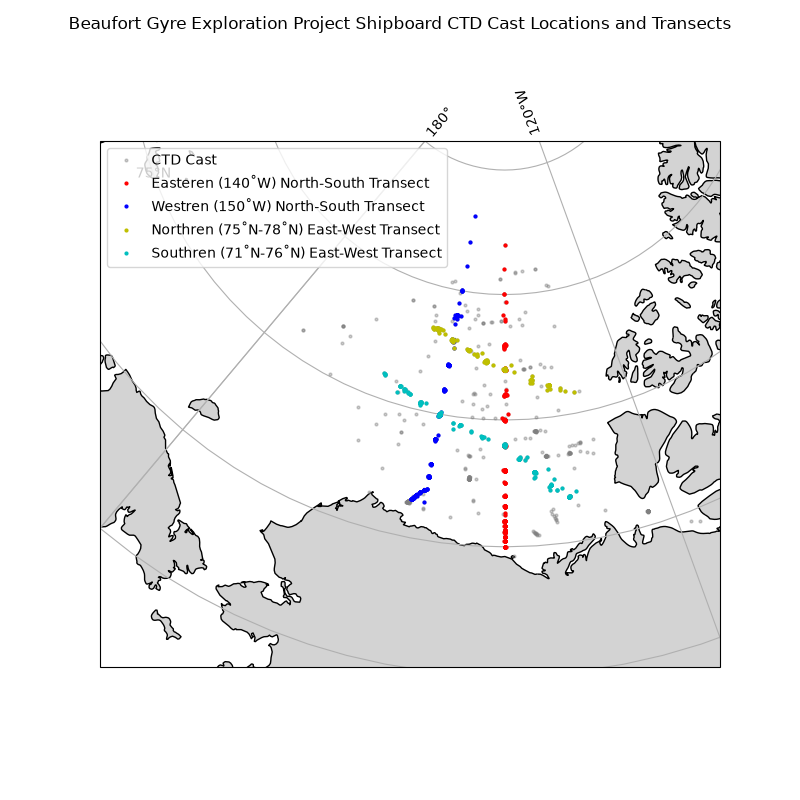

In [6]:
#Plot the transects

#Setup the basemap
transect_location_figure = plt.figure(figsize=(8,8))
projection=ccrs.NorthPolarStereo(central_longitude=-140)
extent = [-180, -120, 65, 85]

ax = mapper.setup_map(figure=transect_location_figure,
                 projection=projection,
                 extent=extent)

#Plot all casts
ax = mapper.plot_station_locations(ax = ax, ds = ds, alpha=0.4, color='gray', label = 'CTD Cast')

#Plat the transects
ax = mapper.plot_station_locations(ax = ax, ds = e_ns_transect, color='r', label = 'Easteren (140˚W) North-South Transect')
ax = mapper.plot_station_locations(ax = ax, ds = w_ns_transect, color='b', label = 'Westren (150˚W) North-South Transect')
ax = mapper.plot_station_locations(ax = ax, ds = n_ew_transect, color='y', label = 'Northren (75˚N-78˚N) East-West Transect')
ax = mapper.plot_station_locations(ax = ax, ds = s_ew_transect, color='c', label = 'Southren (71˚N-76˚N) East-West Transect')



#Finish the plot off
plt.suptitle("Beaufort Gyre Exploration Project Shipboard CTD Cast Locations and Transects") #WHY DOESNT THIS WORK?
plt.legend()

plt.show()

### Preprocess the CTD Transects
* Split each transect dataset into an array of data arrays (one for each cruise year)
* Run the injest/cleaning function on each array of transects to remove nan data, calculate various parameters, ensure all variable naming is consistent, and add variable metadata to easier plotting later on
* Includes calculature thermal wind shear ($\frac{\partial U_g}{\partial z} = \frac{g}{\rho f_c}\frac{\partial \rho}{\partial y}$)

In [7]:
e_ns_cruise_transects = dsops.to_dict_by_cruise(e_ns_transect, process=process_from_scratch, datum = (70,-140))
w_ns_cruise_transects = dsops.to_dict_by_cruise(w_ns_transect, process=process_from_scratch, datum = (70,-150))
n_ew_cruise_transects = dsops.to_dict_by_cruise(n_ew_transect, process=process_from_scratch, datum = (78.4,-154.6))
s_ew_cruise_transects = dsops.to_dict_by_cruise(s_ew_transect, process=process_from_scratch, datum = (76,-160.3))

all_cruise_transects = {
    'e_ns': e_ns_cruise_transects,
    'w_ns': w_ns_cruise_transects,
    'n_ew': n_ew_cruise_transects,
    's_ew': s_ew_cruise_transects
}

### Calculate Absolute Geostrophic Velocity
$\vec{V_g} = \int_{z_0}^{z} \frac{\partial \vec{V_g}}{\partial z} \,dz + \vec{V}_{g, z_0}$
1. Calculate based on a level of no motion of 1000m
2. Calculate based on satelite derived surface geostrophic current


In [8]:
#Load in Satellite Data
sat_data_server = DataServer("/Users/ben/Desktop/3D-TEA-BAG/data/CPOM_DOT.nc", "/Users/ben/Desktop/3D-TEA-BAG/data/Full_DOT_data_Arco_2025_09.nc")

def integrate_agc(cruise_transect_dict):
    for key in cruise_transect_dict:
        transect = cruise_transect_dict[key]

        #1000m level of no motion
        abs_geo_vel = dsops.integrate_from_level_of_no_motion(transect, 1000)
        transect['agv_lnm_1000'] = abs_geo_vel
        #2000m level of no motion
        abs_geo_vel = dsops.integrate_from_level_of_no_motion(transect, 2000)
        transect['agv_lnm_2000'] = abs_geo_vel
        #3000m level of no motion
        abs_geo_vel = dsops.integrate_from_level_of_no_motion(transect, 3000)
        transect['agv_lnm_3000'] = abs_geo_vel


        #Satellite Derived Geostrophic Current
        abs_geo_vel = dsops.integrate_from_surface_current(transect, sat_data_server, 'new', 'ns')
        transect['agv_surf_current'] = abs_geo_vel

        cruise_transect_dict[key] = transect
    return cruise_transect_dict

if process_from_scratch:
    e_ns_cruise_transects = integrate_agc(e_ns_cruise_transects)
    w_ns_cruise_transects = integrate_agc(w_ns_cruise_transects)
    n_ew_cruise_transects = integrate_agc(n_ew_cruise_transects)
    s_ew_cruise_transects = integrate_agc(s_ew_cruise_transects)

In [9]:
if False:
    #Save netCDF files with all new data
    path = "/Users/ben/Desktop/3D-TEA-BAG/data/processed"
    io.writers.save_netCDF_from_dict(e_ns_cruise_transects, f"{path}/e_ns_transect.nc")
    io.writers.save_netCDF_from_dict(w_ns_cruise_transects, f"{path}/w_ns_transect.nc")
    io.writers.save_netCDF_from_dict(n_ew_cruise_transects, f"{path}/n_ew_transect.nc")
    io.writers.save_netCDF_from_dict(s_ew_cruise_transects, f"{path}/s_ew_transect.nc")

#### Interactive Transect Figure

IntSlider(value=2016, continuous_update=False, description='Year:', max=2025, min=2003)

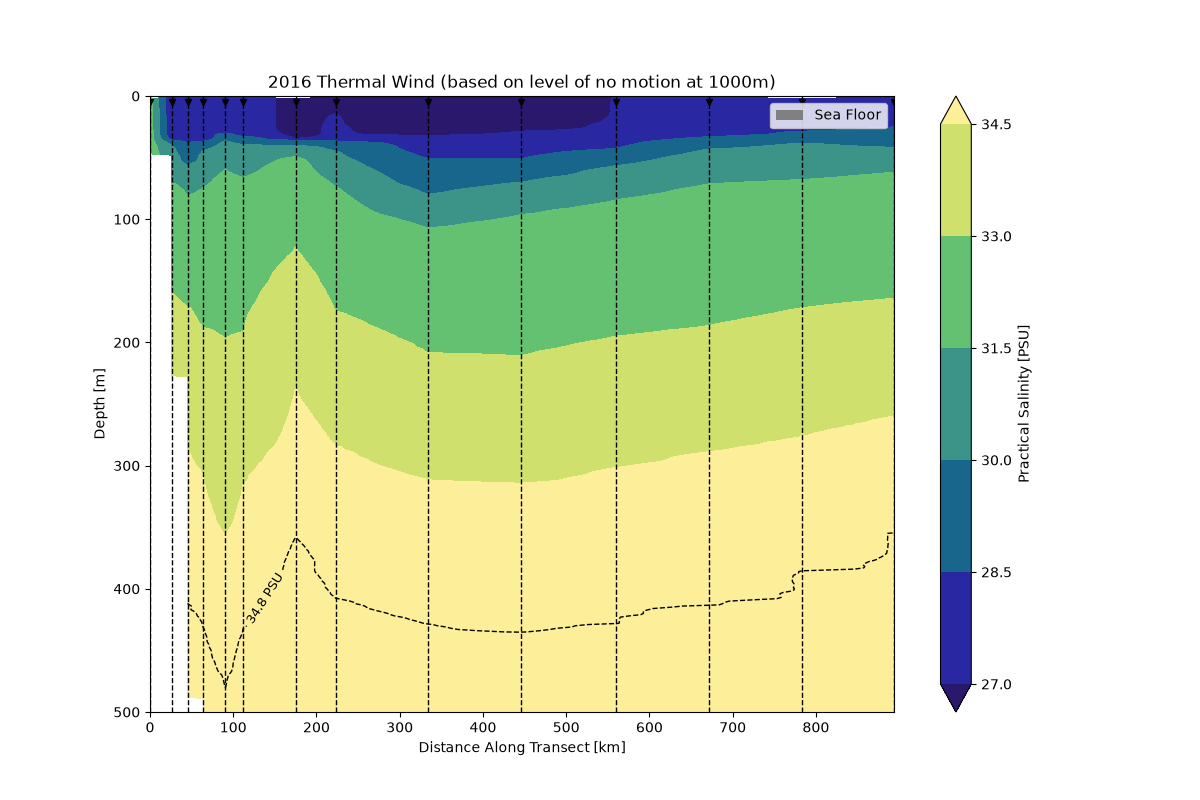

In [10]:
default_year = 2016

fig = plt.figure(figsize=(12,8))

year_slider = widgets.IntSlider(
    value=default_year,
    min=2003,
    max=2025,
    step=1,
    description='Year:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

def plot_lom_transect(change, fig):
    fig.clf()
    ax = fig.add_subplot(1,1,1) 

    year = change['new']
    transect = e_ns_cruise_transects[year]

    fig, ax = sectionPlotter.plot_transect(
        transect=transect,
        x = 'distance',
        y = 'depth',
        data = 'SP',
        fig = fig,
        ax = ax,
        cmap = cm.haline,
        title = f'{year} Thermal Wind (based on level of no motion at 1000m)',
        levels = None,
        bounds = {'top': 0, 'bottom': 500, 'left': 0, 'right': None}
        )


year_slider.observe(lambda b: plot_lom_transect(b, fig), names='value')

display(year_slider)

#Run callback on startup
plot_lom_transect({'new': default_year}, fig,)

plt.show()


### Generate large figure with transects from each year for easy comparison

In [11]:
if False:
    mega_figure = plt.figure(figsize = (24, 16), layout="constrained")

    sns.set_theme()

    data_sets_dicts = [e_ns_cruise_transects, w_ns_cruise_transects, n_ew_cruise_transects, s_ew_cruise_transects]

    track_names = ['140˚W South to North', '150˚W South to North', '78˚-75˚N West to East','76˚-71˚N West to East']
    file_names = ['ns_e', 'ns_w', 'ew_n', 'ew_s']
    right_limits = [900, 1100, 600, 1100]

    variable = 'agv_lnm_3000'

    for i, transect_dict in enumerate(data_sets_dicts):
        track_name = track_names[i]
        mega_figure.clf()
        axs = mega_figure.subplots(4,6)
        for j, key in enumerate(transect_dict):
            year = key
            transect = transect_dict[year]

            index = np.unravel_index(j, (4,6))

            mega_figure, axs[index], cbar_obj = sectionPlotter.plot_transect(
                transect=transect,
                x = 'distance',
                y = 'depth',
                data = variable,
                fig = mega_figure,
                ax = axs[index],
                cmap = colormaps['seismic'],
                title = str(year),
                levels = 0.075,
                colorbar = False,
                bounds = {'top': 0, 'bottom': 600, 'left': 0, 'right': right_limits[i]},
                xlabel=False,
                ylabel=False,
                legend=False,
                seafloor=False
            )

        mega_figure.suptitle(f"{track_name} Transect Absolute Geostrophic Current from 3000m Level of No Motion")
        mega_figure.supxlabel("Distance Along Transect [km]")
        mega_figure.supylabel("Depth [m]")
        mega_figure.colorbar(cbar_obj, ax = axs, label = "Absolute Geostrophic Current [m/s]", shrink = 0.5)
        file_name = f"{file_names[i]}_{variable}.png"
        plt.savefig(f"/Users/ben/Desktop/3D-TEA-BAG/plots/{file_name}")


#### Depth Averaged Geostrophic Velocity (down to 34.8 PSU contour)

#### Cumulative Transport (down to 34.8 PSU contour)

In [12]:
for transect_dict_id in all_cruise_transects:
    transect_dict = all_cruise_transects[transect_dict_id]
    for cruise_id in transect_dict:
        transect = transect_dict[cruise_id]
        mask = transect['depth'] <= transect['isohaline_depth']
        gyre = transect.where(mask)
        transect['depth_int_transport_surf_current'] = ('station', list(gyre.sel(station = station_id)['agv_surf_current'].dropna(dim = 'depth').integrate('depth').values for station_id in gyre['station']))
        working_transect = transect.swap_dims({'station': 'distance'})
        working_transect['distance'] = working_transect['distance']*1000
        transport = working_transect['depth_int_transport_surf_current'].cumulative_integrate('distance')/1e6
        all_cruise_transects[transect_dict_id][cruise_id]['cumulative_transport_surf_current'] = (('station'), transport.values)
        all_cruise_transects[transect_dict_id][cruise_id]['depth_int_transport_surf_current'].attrs.update({
            'units': 'm^2/s',
            'long_name': 'Depth Integrated Transport',
            'standard_name': 'depth_integrated_transport',
        })
        all_cruise_transects[transect_dict_id][cruise_id]['cumulative_transport_surf_current'].attrs.update({
            'units': 'Sv',
            'long_name': 'Cumulative Transport',
            'standard_name': 'cumulative_transport',
        })
        

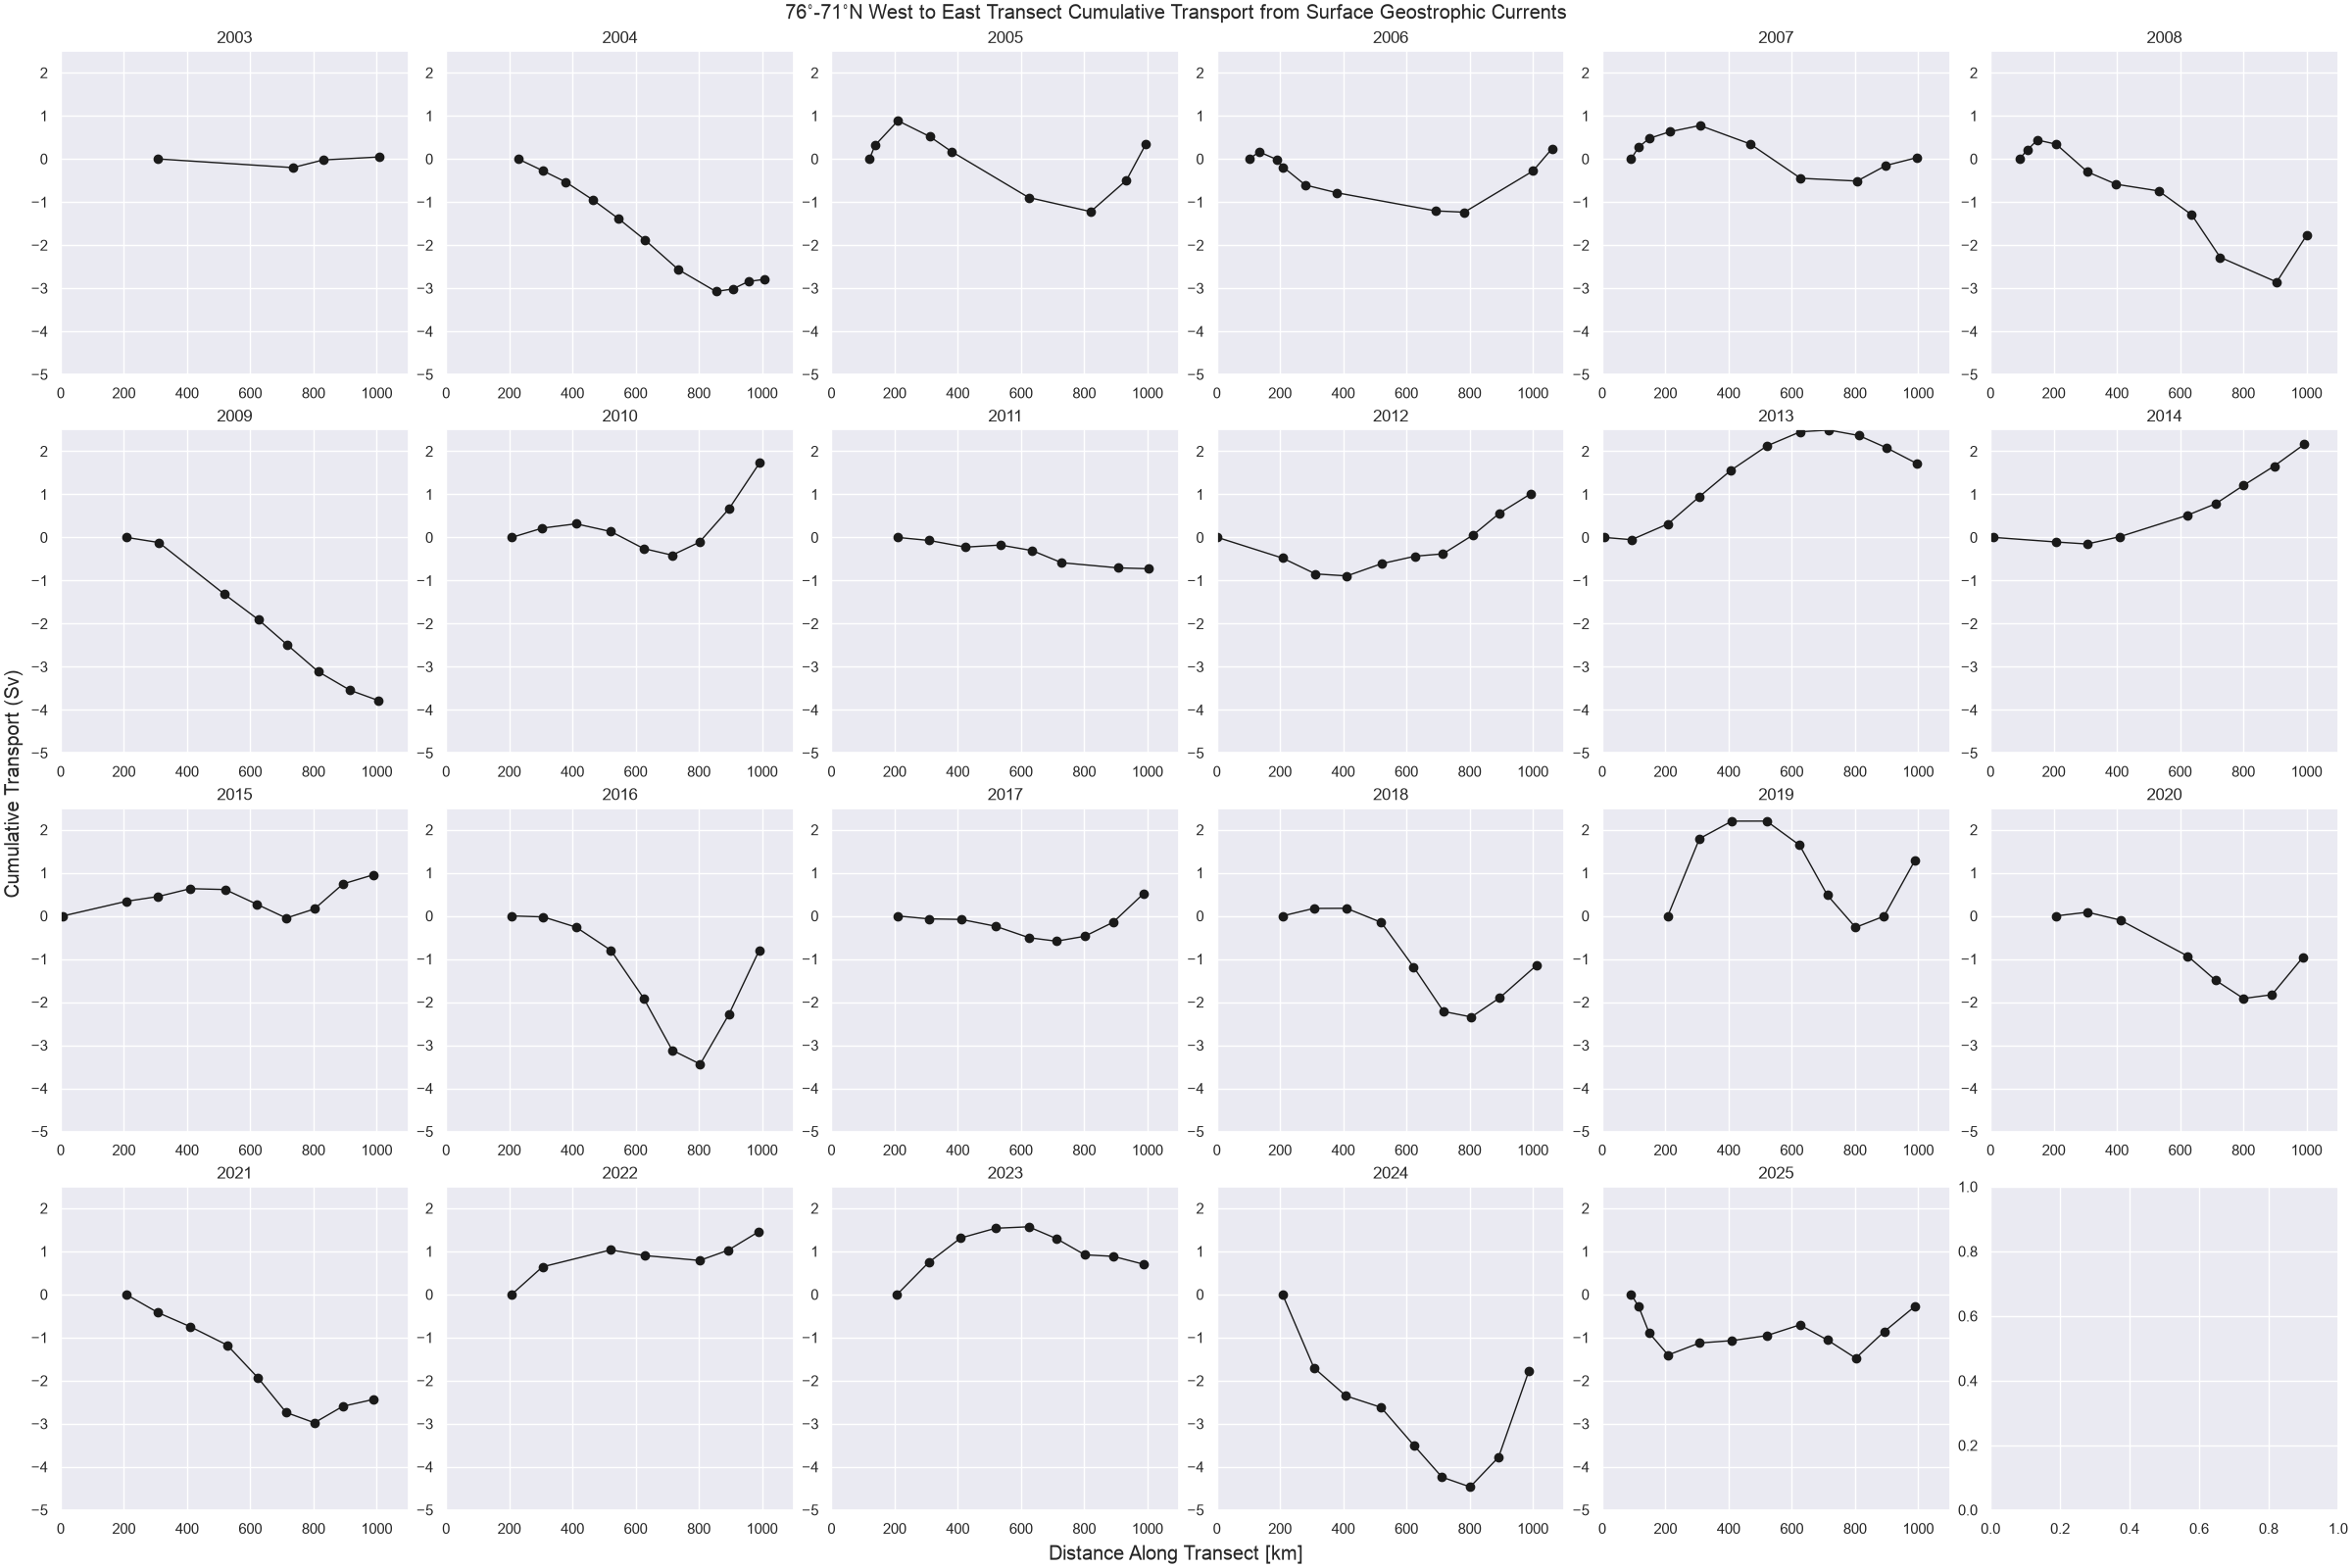

In [13]:
mega_figure = plt.figure(figsize = (24, 16), layout="constrained")

sns.set_theme()

data_sets_dicts = [e_ns_cruise_transects, w_ns_cruise_transects, n_ew_cruise_transects, s_ew_cruise_transects]

track_names = ['140˚W South to North', '150˚W South to North', '78˚-75˚N West to East','76˚-71˚N West to East']
file_names = ['ns_e', 'ns_w', 'ew_n', 'ew_s']
right_limits = [900, 1100, 600, 1100]
top_limits = [3.5, 3, 1, 2.5]
bottom_limits = [-5.5, -11, -6.5, -5]

variable = 'cumulative_transport_surf_current'


for i, transect_dict in enumerate(data_sets_dicts):
    track_name = track_names[i]
    mega_figure.clf()
    axs = mega_figure.subplots(4,6)
    for j, key in enumerate(transect_dict):
        year = key
        transect = transect_dict[year]

        index = np.unravel_index(j, (4,6))
        
        mega_figure, axs[index] = twoDPlotter.plot_variable(
            transect=transect,
            x = 'distance',
            y = variable,
            fig = mega_figure,
            ax = axs[index],
            title = str(year),
            bounds = {'top': top_limits[i], 'bottom': bottom_limits[i], 'left': 0, 'right': right_limits[i]},
            xlabel=False,
            ylabel=False,
            legend=False,
        )

    mega_figure.suptitle(f"{track_name} Transect Cumulative Transport from Surface Geostrophic Currents")
    mega_figure.supxlabel("Distance Along Transect [km]")
    mega_figure.supylabel("Cumulative Transport (Sv)")
    file_name = f"{file_names[i]}_{variable}.png"
    plt.savefig(f"/Users/ben/Desktop/3D-TEA-BAG/plots/{file_name}")

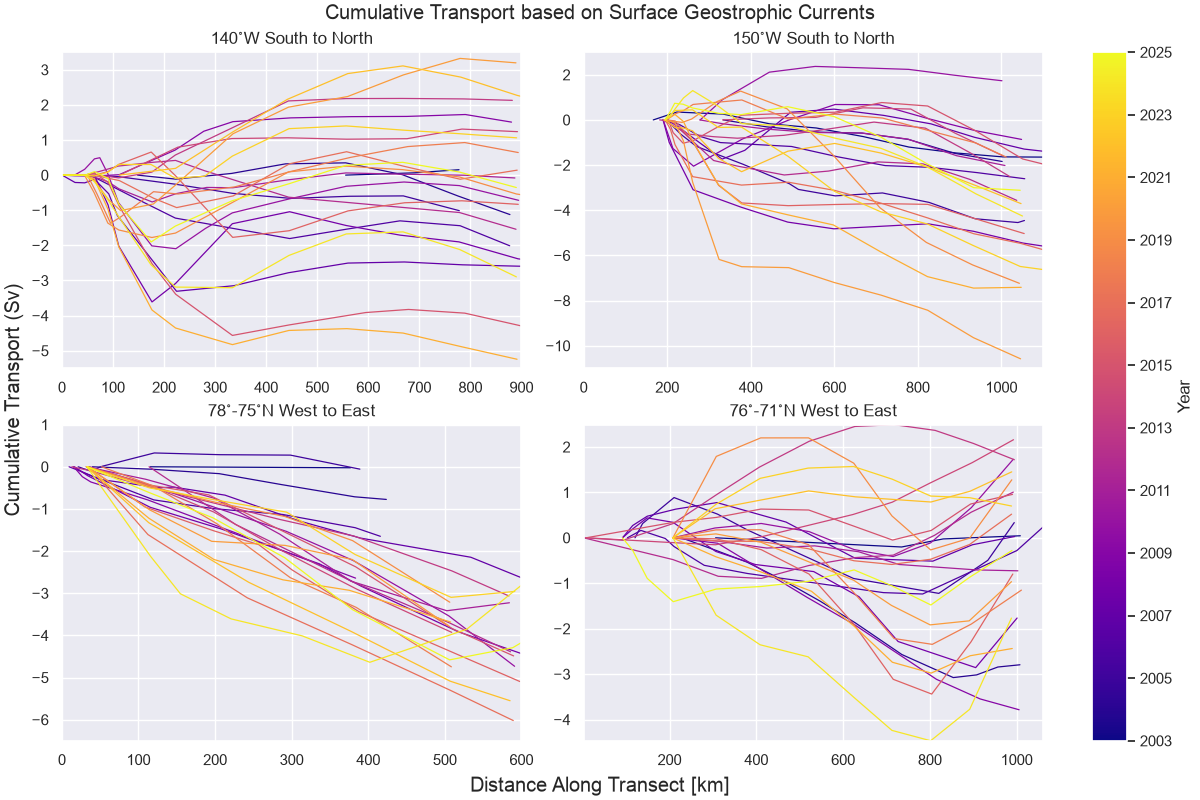

In [14]:
mega_figure = plt.figure(figsize = (12, 8), layout="constrained")
axs = mega_figure.subplots(2,2)


sns.set_theme()

data_sets_dicts = [e_ns_cruise_transects, w_ns_cruise_transects, n_ew_cruise_transects, s_ew_cruise_transects]

track_names = ['140˚W South to North', '150˚W South to North', '78˚-75˚N West to East','76˚-71˚N West to East']
file_names = ['ns_e', 'ns_w', 'ew_n', 'ew_s']
right_limits = [900, 1100, 600, 1100]
top_limits = [3.5, 3, 1, 2.5]
bottom_limits = [-5.5, -11, -6.5, -5]

variable = 'cumulative_transport_surf_current'

years = np.array(list(data_sets_dicts[0]))
colors = plt.cm.plasma(np.linspace(0, 1, len(years)))


for i, transect_dict in enumerate(data_sets_dicts):
    track_name = track_names[i]
    index = np.unravel_index(i, (2,2))

    for j, key in enumerate(transect_dict):
        transect = transect_dict[key]

        
        mega_figure, axs[index] = twoDPlotter.plot_variable(
            transect=transect,
            x = 'distance',
            y = variable,
            fig = mega_figure,
            ax = axs[index],
            title = str(track_name),
            bounds = {'top': top_limits[i], 'bottom': bottom_limits[i], 'left': 0, 'right': right_limits[i]},
            color=colors[j],
            marker=None,
            linewidth=0.9,
            xlabel=False,
            ylabel=False,
            legend=False,
        )
    plt.autoscale(enable=True, axis='x', tight=True)
    plt.autoscale(enable=True, axis='y', tight=True)    
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(years.min(), years.max()))
sm.set_array([])
cbar = mega_figure.colorbar(sm, ax=axs)
cbar.set_label('Year')
tick_years = years[::2]  # every other year
cbar.set_ticks(tick_years)
cbar.set_ticklabels([str(y) for y in tick_years])

mega_figure.suptitle(f"Cumulative Transport based on Surface Geostrophic Currents")
mega_figure.supxlabel("Distance Along Transect [km]")
mega_figure.supylabel("Cumulative Transport (Sv)")
file_name = f"year_by_year_{variable}.png"
plt.show()

# plt.savefig(f"/Users/ben/Desktop/3D-TEA-BAG/plots/{file_name}")

#### Find and Plot the location of the Beaufort Gyre
The location of the Beaufot Gyre is plotted using the method described in Regan, et. al (2018). The location of the gyre is defined at the point of maximum DOT between 140˚E and 100˚W and 68-81.5˚N.

 the so-called "Beaufort Gyre Box" as defined in Proshutinsky et al., 2009 (with bounds 130-170˚W and 70.5-80.5˚N)

In [41]:
#Get raw satellite data Datasets
old_sat_data_ds, new_sat_data_ds = sat_data_server.datasets()

#Extract data from within the Beaufort Gyre box
lat_min, lat_max = 68, 81.5
lon_min, lon_max = 140, -100

#Old data (gridded on a 0.25˚ lat/lon grid)
if lon_min>lon_max:
    #If range crosses the int. date line
    mask = (
            (old_sat_data_ds.lat >= lat_min) & (old_sat_data_ds.lat <= lat_max) &
            ((old_sat_data_ds.lon >= lon_min) | (old_sat_data_ds.lon <= lon_max))
        )

    old_bg_ds = old_sat_data_ds.where(mask, drop=True)
else:
    old_bg_ds = old_sat_data_ds.sel(lat = slice(lat_min, lat_max), lon = slice(lon_min, lon_max))

#New data (gridded on a 20km grid on a polar stereographic projection)
if lon_min>lon_max:
    #If range crosses the int. date line
    mask = (
        (new_sat_data_ds.lat >= lat_min) & (new_sat_data_ds.lat <= lat_max) &
        ((new_sat_data_ds.lon >= lon_min) | (new_sat_data_ds.lon <= lon_max))
    )
else:
    mask = (
            (new_sat_data_ds.lat >= lat_min) & (new_sat_data_ds.lat <= lat_max) &
            (new_sat_data_ds.lon >= lon_min) & (new_sat_data_ds.lon <= lon_max)
        )

new_bg_ds = new_sat_data_ds.where(mask, drop=True)

#Discard all data not from September
old_bg_ds = old_bg_ds.where(old_bg_ds['time'].dt.month == 9, drop = True)
new_bg_ds = new_bg_ds.where(new_bg_ds['time'].dt.month == 9, drop = True)


In [ ]:
#Find max DOT for each year
old_max_DOT_dict = old_bg_ds['DOT'].argmax(dim = ['lat', 'lon'])
new_max_DOT_dict = new_bg_ds['DOT'].argmax(dim=['x','y'])

#Extract lat/lon coordinates and DOT value from coordinate array indicies from argmax
old_lats, old_lons = old_bg_ds['lat'][old_max_DOT_dict['lat']].values.copy(), old_bg_ds['lon'][old_max_DOT_dict['lon']].values.copy()
old_DOT = np.full_like(old_lats, np.nan)
old_x = old_max_DOT_dict['lat']
old_y = old_max_DOT_dict['lon']
for i in range (old_DOT.size):
    old_DOT[i] = old_bg_ds['DOT'].sel(lat = old_lats[i], lon = old_lons[i]).values.copy()[i]

new_lats, new_lons, new_DOT = new_bg_ds['lat'].sel(x = new_max_DOT_dict['x'], y = new_max_DOT_dict['y']), new_bg_ds['lon'].sel(x = new_max_DOT_dict['x'], y = new_max_DOT_dict['y']), new_bg_ds['DOT'].sel(x = new_max_DOT_dict['x'], y = new_max_DOT_dict['y'])
new_x = new_max_DOT_dict['x']
new_y = new_max_DOT_dict['y']

#Define function to find the x and y coords of a DOT value at a known lat/lon
def find_x_y(full_bg_dataarray, DOT_value, lat, lon, era):
    output = [np.nan, np.nan]
    if era == 'old':
        #x and y coords can be extracted directly from the lat/lon array
        output[0] = np.argwhere(full_bg_dataarray['lat'].values == lat)[0][0]
        output[1] = np.argwhere(full_bg_dataarray['lon'].values == lon)[0][0]
    if era == 'new':
        #Get all possible coordinates
        candidates = np.argwhere(full_bg_dataarray['DOT'].values == DOT_value)[0]
        for index in candidates:
            #Work through the candidates until there is a match with the known lat/lon
            two_d_coordinate = np.unravel_index(index, full_bg_dataarray['lat'].shape)
            if full_bg_dataarray['lat'][two_d_coordinate] == lat & full_bg_dataarray['lon'][two_d_coordinate] == lon:
                #There is a match
                output = two_d_coordinate

    return output

#Redo calculation for 2003 because of a large "hill" near the bearing straight that is not the Beaufort Gyre
#Exclude data west of 160˚W and south of 71.5˚N
two_thousand_three_data = old_bg_ds.where(old_bg_ds['time'].dt.year == 2003, drop = True).sel(lat = slice(71.5, lat_max), lon = slice(-160,lon_max))
two_thousand_three_dict = two_thousand_three_data['DOT'].argmax(dim = ['lat', 'lon'])
lat = two_thousand_three_data['lat'][two_thousand_three_dict['lat']].values[0]
lon = two_thousand_three_data['lon'][two_thousand_three_dict['lon']].values[0]
DOT = two_thousand_three_data.sel(lat = lat, lon = lon)['DOT'].values[0]
print(lat)
print(lon)
old_bg_ds['lat'][0], old_bg_ds['lon'][0] = find_x_y(old_bg_ds.where(old_bg_ds['time'].dt.year == 2003, drop = True), DOT, lat, lon, 'old'))
old_x[0] = two_thousand_three_dict['lat']
old_y[0] = two_thousand_three_dict['lon']

#Redo calculation for 2005 because of a large "hill" west of the the bearing straight that is not the Beaufort Gyre
#Exclude data south of 71.5˚N
two_thousand_five_data = old_bg_ds.where(old_bg_ds['time'].dt.year == 2005, drop = True).sel(lat = slice(71.5, lat_max))
two_thousand_five_dict = two_thousand_five_data['DOT'].argmax(dim = ['lat', 'lon'])
old_lats[2] = (lat := two_thousand_five_data['lat'][two_thousand_five_dict['lat']].values[0])
old_lons[2] = (lon := two_thousand_five_data['lon'][two_thousand_five_dict['lon']].values[0])
old_DOT[2] = two_thousand_five_data.sel(lat = lat, lon = lon)['DOT'].values[0]
old_x[2] = two_thousand_five_dict['lat']
old_y[2] = two_thousand_five_dict['lon']

#Redo calculation for 2006 because of a large "hill" near the bearing straight that is not the Beaufort Gyre
#Exclude data west of 160˚W and south of 71.5˚N
two_thousand_six_data = old_bg_ds.where(old_bg_ds['time'].dt.year == 2006, drop = True).sel(lat = slice(71.5, lat_max), lon = slice(-160,lon_max))
two_thousand_six_dict = two_thousand_six_data['DOT'].argmax(dim = ['lat', 'lon'])
old_lats[3] = (lat := two_thousand_six_data['lat'][two_thousand_six_dict['lat']].values[0])
old_lons[3] = (lon := two_thousand_six_data['lon'][two_thousand_six_dict['lon']].values[0])
old_DOT[3] = two_thousand_six_data.sel(lat = lat, lon = lon)['DOT'].values[0]
old_x[3] = two_thousand_six_dict['lat']
old_y[3] = two_thousand_six_dict['lon']


#Redo calculation for 2024 because of an eddy east of the BG
#Exclude data east of 134˚W
two_thousand_twenty_four_data = new_bg_ds.where(time_mask := new_bg_ds['time'].dt.year == 2024, drop = True)
if lon_min>-134:
    #If range crosses the int. date line
    mask = (
        (two_thousand_twenty_four_data.lat >= lat_min) & (two_thousand_twenty_four_data.lat <= lat_max) &
        ((two_thousand_twenty_four_data.lon >= lon_min) | (two_thousand_twenty_four_data.lon <= -134))
    )
else:
    mask = (
            (two_thousand_twenty_four_data.lat >= lat_min) & (two_thousand_twenty_four_data.lat <= lat_max) &
            (two_thousand_twenty_four_data.lon >= lon_min) & (two_thousand_twenty_four_data.lon <= -134)
        )

two_thousand_twenty_four_data = two_thousand_twenty_four_data.where(mask, drop=True)
two_thousand_twenty_four_dict = two_thousand_twenty_four_data['DOT'].argmax(dim = ['x', 'y'])
new_lats[13] = two_thousand_twenty_four_data.sel(x = two_thousand_twenty_four_dict['x'], y=two_thousand_twenty_four_dict['y'])['lat'].values[0]
new_lons[13] = two_thousand_twenty_four_data.sel(x = two_thousand_twenty_four_dict['x'], y=two_thousand_twenty_four_dict['y'])['lon'].values[0]
new_DOT[13] = two_thousand_twenty_four_data.sel(x = two_thousand_twenty_four_dict['x'], y=two_thousand_twenty_four_dict['y'])['DOT'].values[0]
new_x[2] = two_thousand_twenty_four_dict['x']
new_y[2] = two_thousand_twenty_four_dict['y']


#Package into a Dataset for easy access
times = np.unique(np.concat((old_bg_ds.time, new_bg_ds.time)))
old_padding_size = (times.size-old_bg_ds.time.size,) #Size of padding to add after any old data
new_padding_size = (times.size-new_bg_ds.time.size,) #Size of padding to add before any new data
era = np.array(['old', 'new'], dtype=str)

page_size = (era.size, times.size)

#Assemble data
old_data_arrays = [old_lats, old_lons, old_DOT, old_x, old_y]
new_data_arrays = [new_lats, new_lons, new_DOT, new_x, new_y]
data = np.ndarray(shape=(era.size, times.size,len(old_data_arrays)))

for i in range(len(old_data_arrays)):
    old_row = np.hstack((old_data_arrays[i], np.full(old_padding_size, np.nan)))
    new_row = np.hstack((np.full(new_padding_size, np.nan), new_data_arrays[i]))
    data[:,:,i] = np.vstack((old_row, new_row))

#Create Dataset
max_DOT_ds = xr.Dataset(
    {
        "lat": 
            (['era', 'time'],
             data[:,:,0],
             {"units": "degrees",
              "long_name": "Latitude",
              'standard_name': "latitude"}),
        "lon": 
            (['era', 'time'],
                data[:,:,1],
                {"units": "degrees",
                "long_name": "Longitude",
                'standard_name': "longitude"}),
        "DOT": 
            (['era', 'time'],
                data[:,:,2],
                {"units": "meters",
                "long_name": "Dynamic Ocean Topography",
                'standard_name': "DOT"}),
        "x":
            (['era', 'time'],
             data[:,:,3],
             {"units": "array index"}),
        "y":
            (['era', 'time'],
                data[:,:,4],
                {"units": "array index"}),
    },
    coords={
        "time": times,
        "era": era,
    },
    attrs = {
        "title": "Location of the Beaufort Gyre based on max DOT"
    }
)

73.75
-147.75
[np.int64(23), np.int64(42)]


IndexError: dimension coordinate 'time' conflicts between indexed and indexing objects:
<xarray.DataArray 'time' (time: 1)> Size: 8B
array(['2003-09-01T00:00:00.000000'], dtype='datetime64[us]')
Coordinates:
  * time     (time) datetime64[us] 8B 2003-09-01
vs.
<xarray.Variable ()> Size: 8B
array('2003-09-01T00:00:00.000000', dtype='datetime64[us]')

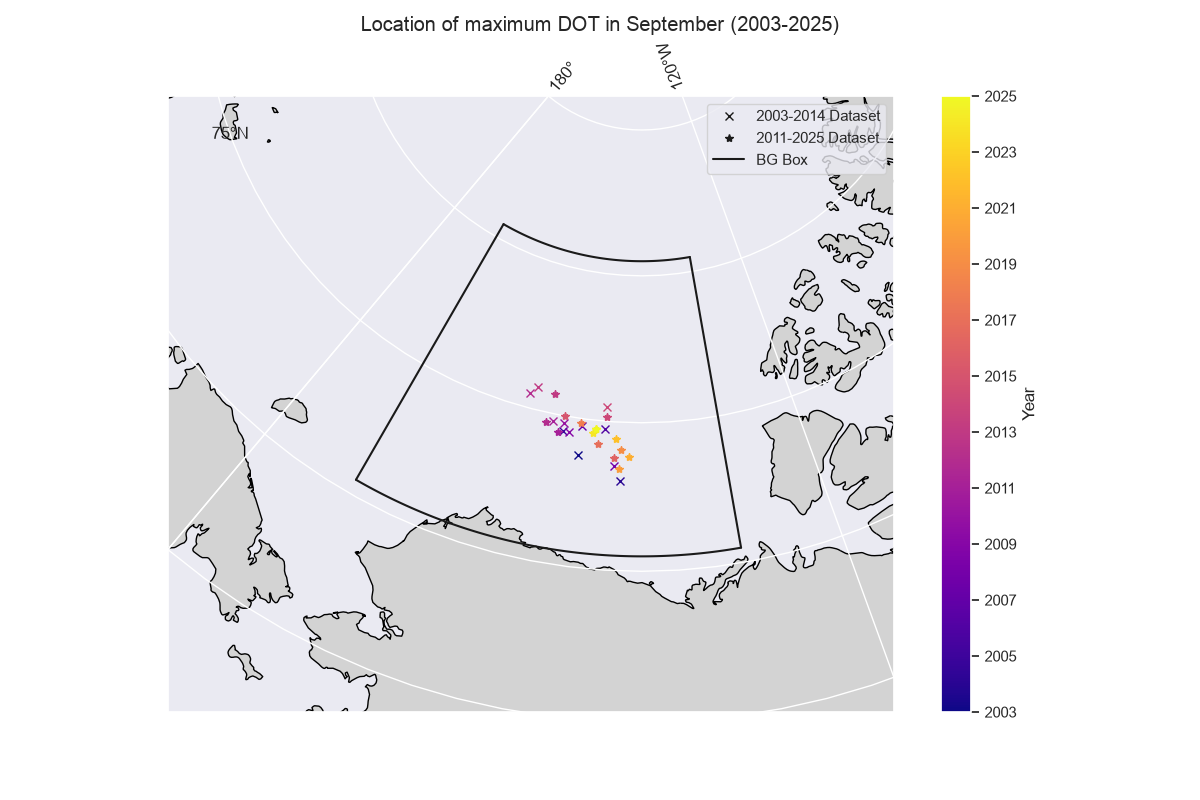

In [191]:
#Plot location of max DOT
extent = [-180, -120, 65, 85]

dot_figure = plt.figure(figsize=(12,8))
projection=ccrs.NorthPolarStereo(central_longitude=-140)
ax = mapper.setup_map(figure=dot_figure,
                      projection=projection,
                      extent=extent)

sns.set_theme()

years = max_DOT_ds['time'].dt.year
colors = plt.cm.plasma(np.linspace(0, 1, len(years)))


for i, year in enumerate(years):
    working_data = max_DOT_ds.where(max_DOT_ds['time'].dt.year == year)
    #Plot old data
    ax.plot(working_data.sel(era = 'old')['lon'], working_data.sel(era = 'old')['lat'], marker = 'x', color = colors[i], transform = ccrs.PlateCarree())

    #Plot new data
    ax.plot(working_data.sel(era = 'new')['lon'], working_data.sel(era = 'new')['lat'], marker = '*', color = colors[i], transform = ccrs.PlateCarree())
    
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(years.min(), years.max()))
sm.set_array([])
cbar = dot_figure.colorbar(sm, ax=ax)
cbar.set_label('Year')
tick_years = years.values[::2]  # every other year
cbar.set_ticks(tick_years)
cbar.set_ticklabels([str(y) for y in tick_years])

#Create dummy points for the legend
ax.plot([],[],'kx', label = '2003-2014 Dataset')
ax.plot([],[],'k*', label = '2011-2025 Dataset')

#Plot the Beaufort Gyre Box
top_bottom_lon= np.linspace(-170, -130, 100)
top_lat = np.full_like(top_bottom_lon, 80.5)
bottom_lat = np.full_like(top_bottom_lon, 70.5)
ax.plot([-170, -170], [70.5, 80.5], 'k-', transform = ccrs.PlateCarree(), label = 'BG Box')
ax.plot([-130, -130], [70.5, 80.5], 'k-', transform = ccrs.PlateCarree())
ax.plot(top_bottom_lon, top_lat, 'k-', transform = ccrs.PlateCarree())
ax.plot(top_bottom_lon, bottom_lat, 'k-', transform = ccrs.PlateCarree())

ax.legend()

dot_figure.suptitle("Location of maximum DOT in September (2003-2025)")


plt.show()

In [222]:
old_bg_ds.sel(time = np.datetime64('2003-09-01'))['DOT'][23][42]


<xarray.DataArray 'DOT' ()> Size: 4B
array(0.38747028, dtype=float32)
Coordinates:
    lon      float32 4B -147.8
    lat      float32 4B 73.75
    time     datetime64[us] 8B 2003-09-01
Attributes:
    units:    m

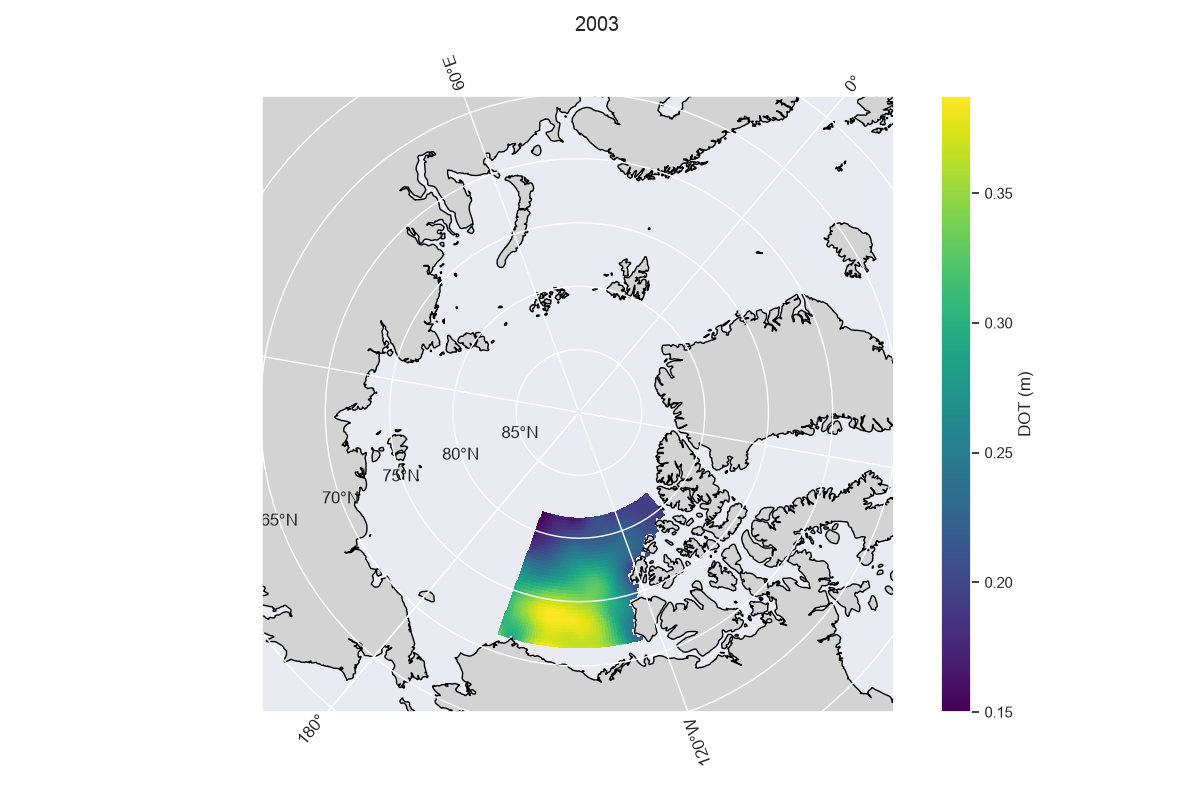

In [114]:
if True:
    #Plot single year DOT
    # extent = [-180, -120, 65, 85]
    extent = [-120, 140, 65, 85]


    year = 2003

    sat_data = old_sat_data_ds.sel(lat = slice(71, lat_max), lon = slice(-180, -120)).where(old_sat_data_ds['time'].dt.year == year, drop=True)
    sat_data = sat_data.where(sat_data['time'].dt.month == 9, drop=True)

    # sat_data = new_sat_data_ds.where(new_sat_data_ds['time'].dt.year == year, drop=True)
    # sat_data = sat_data.where(sat_data['time'].dt.month == 9, drop=True)
    # mask = (
    #             (new_sat_data_ds.lat >= lat_min) & (new_sat_data_ds.lat <= lat_max) &
    #             ((new_sat_data_ds.lon >= lon_min) | (new_sat_data_ds.lon <= -134))
    #         )

    # sat_data = sat_data.where(mask, drop=True)

    year_dot_figure = plt.figure(figsize=(12,8))
    projection=ccrs.NorthPolarStereo(central_longitude=-140)
    ax = mapper.setup_map(figure=year_dot_figure,
                        projection=projection,
                        extent=extent)

    sns.set_theme()

    sat_data = two_thousand_three_data.sel(time = two_thousand_three_data['time'][0])

    lon_mesh, lat_mesh = np.meshgrid(sat_data['lon'], sat_data['lat'])
    mesh = ax.pcolormesh(lon_mesh, lat_mesh, sat_data['DOT'], cmap = 'viridis', shading='auto', transform = ccrs.PlateCarree())
    # step = 2
    # # mesh = ax.quiver(x = sat_data['lon'].values[::step],  y = sat_data['lat'].values[::step], u = sat_data['U'].values[::step], v = sat_data["V"].values[::step], cmap='viridis', transform = ccrs.PlateCarree())
    # dir = angle_rad = (np.arctan2(sat_data["V"].values, sat_data["U"].values)*180/np.pi +360) % 360 
    # mesh = ax.scatter(sat_data['lon'].values, sat_data['lat'].values, c= sat_data['DOT'].values, cmap='viridis', s = 8, transform = ccrs.PlateCarree())

    plt.colorbar(mesh, label = 'DOT (m)')
    year_dot_figure.suptitle("2003 ")

    plt.show()

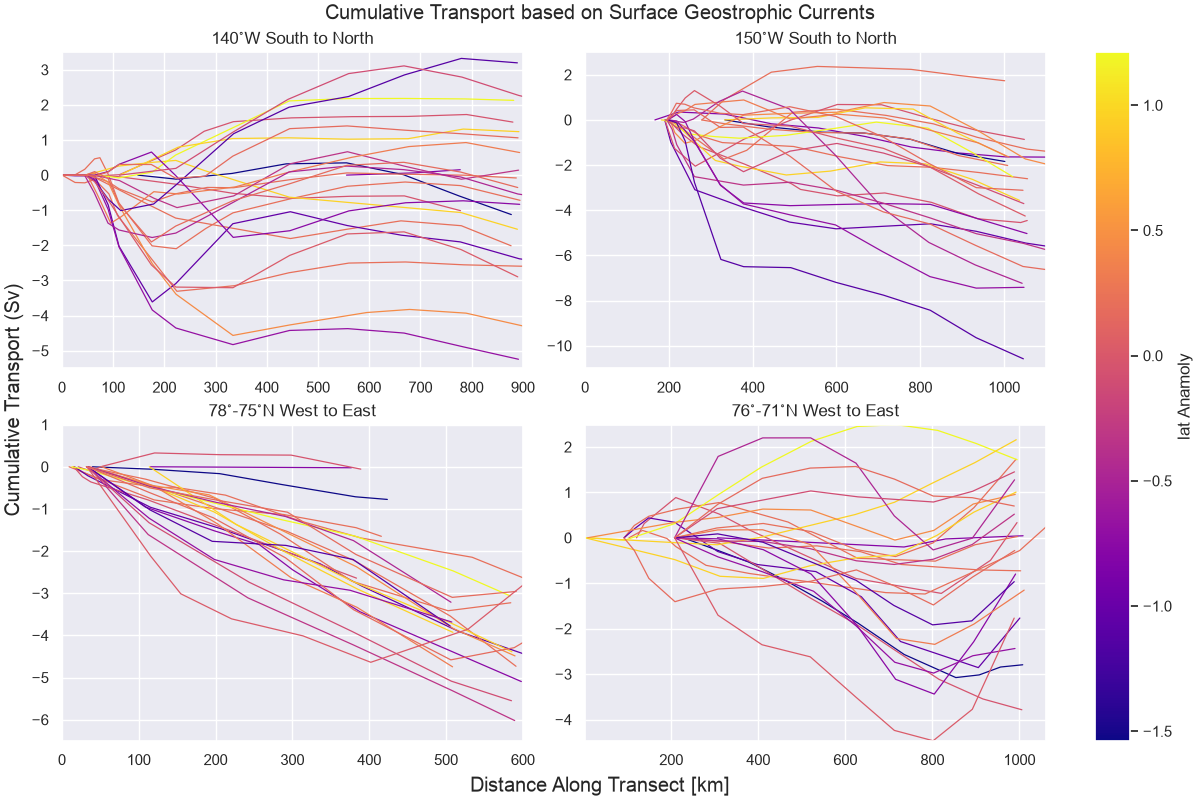

In [195]:
mega_figure = plt.figure(figsize = (12, 8), layout="constrained")
axs = mega_figure.subplots(2,2)


sns.set_theme()

data_sets_dicts = [e_ns_cruise_transects, w_ns_cruise_transects, n_ew_cruise_transects, s_ew_cruise_transects]

track_names = ['140˚W South to North', '150˚W South to North', '78˚-75˚N West to East','76˚-71˚N West to East']
file_names = ['ns_e', 'ns_w', 'ew_n', 'ew_s']
right_limits = [900, 1100, 600, 1100]
top_limits = [3.5, 3, 1, 2.5]
bottom_limits = [-5.5, -11, -6.5, -5]

variable = 'cumulative_transport_surf_current'

# years = np.array(list(data_sets_dicts[0]), dtype=np.int16)
# norm = plt.Normalize(years.min(), years.max())
# colors = plt.cm.plasma(norm(years))

color_var = 'lat'
years = np.array(list(data_sets_dicts[0]))
lat_anamoly = max_DOT_ds[color_var]-max_DOT_ds[color_var].mean()
lat_anamoly_flat = lat_anamoly[0,:]
lat_anamoly_flat[12:] = lat_anamoly[1,12:]
norm = Normalize(lat_anamoly_flat.min(), lat_anamoly_flat.max())
colors = plt.cm.plasma(norm(lat_anamoly_flat))



for i, transect_dict in enumerate(data_sets_dicts):
    track_name = track_names[i]
    index = np.unravel_index(i, (2,2))

    for j, key in enumerate(transect_dict):
        transect = transect_dict[key]

        
        mega_figure, axs[index] = twoDPlotter.plot_variable(
            transect=transect,
            x = 'distance',
            y = variable,
            fig = mega_figure,
            ax = axs[index],
            title = str(track_name),
            bounds = {'top': top_limits[i], 'bottom': bottom_limits[i], 'left': 0, 'right': right_limits[i]},
            color=colors[j],
            marker=None,
            linewidth=0.9,
            xlabel=False,
            ylabel=False,
            legend=False,
        )
    plt.autoscale(enable=True, axis='x', tight=True)
    plt.autoscale(enable=True, axis='y', tight=True)    
sm = plt.cm.ScalarMappable(cmap='plasma', norm = norm)
sm.set_array([])
cbar = mega_figure.colorbar(sm, ax=axs)
cbar.set_label(f'{color_var} Anamoly')
# step = 2
# cbar.set_ticks(years[::step])
# cbar.set_ticklabels(years[::step].astype(str))


mega_figure.suptitle(f"Cumulative Transport based on Surface Geostrophic Currents")
mega_figure.supxlabel("Distance Along Transect [km]")
mega_figure.supylabel("Cumulative Transport (Sv)")
file_name = f"year_by_year_{variable}.png"
plt.show()

# # plt.savefig(f"/Users/ben/Desktop/3D-TEA-BAG/plots/{file_name}")

#### Find Closed Lowest Closed Contour

In [ ]:

era = 'new'
time = np.datetime64('2022-09-01')

data = new_bg_ds.sel(time = time)['DOT'].values
working_DOT_da = max_DOT_ds.sel(time = time, era = era)
while working_height > np.nanmin(data):
    #Work down from the max height to find the lowest closed contour that contains the max DOT point 

    #Get the location of the max DOT point in array coordinate space
    working_x_coord = working_DOT_da['x']
    working_y_coord = working_DOT_da['y']

    #Find all contours at that level
    contours = measure.find_contours(data, working_height)

    if np.array(mask := [np.isclose(contour[0], contour[-1]).all() for contour in contours]).any():
        #There is a closed contour, check if it contains the max DOT point
        for i, contour in enumerate(contours):
            if mask[i]:
                closed_contour = []
                for coord in contour:
                    closed_contour.append([int(index.round()) for index in coord])
                break
        break
    working_height -= 0.01


closed_lat = [new_bg_ds.sel(time = np.datetime64('2023-09-01'))['lat'].values[coord[0]][coord[1]] for coord in closed_contour]
closed_lon = [new_bg_ds.sel(time = np.datetime64('2023-09-01'))['lon'].values[coord[0]][coord[1]] for coord in closed_contour]





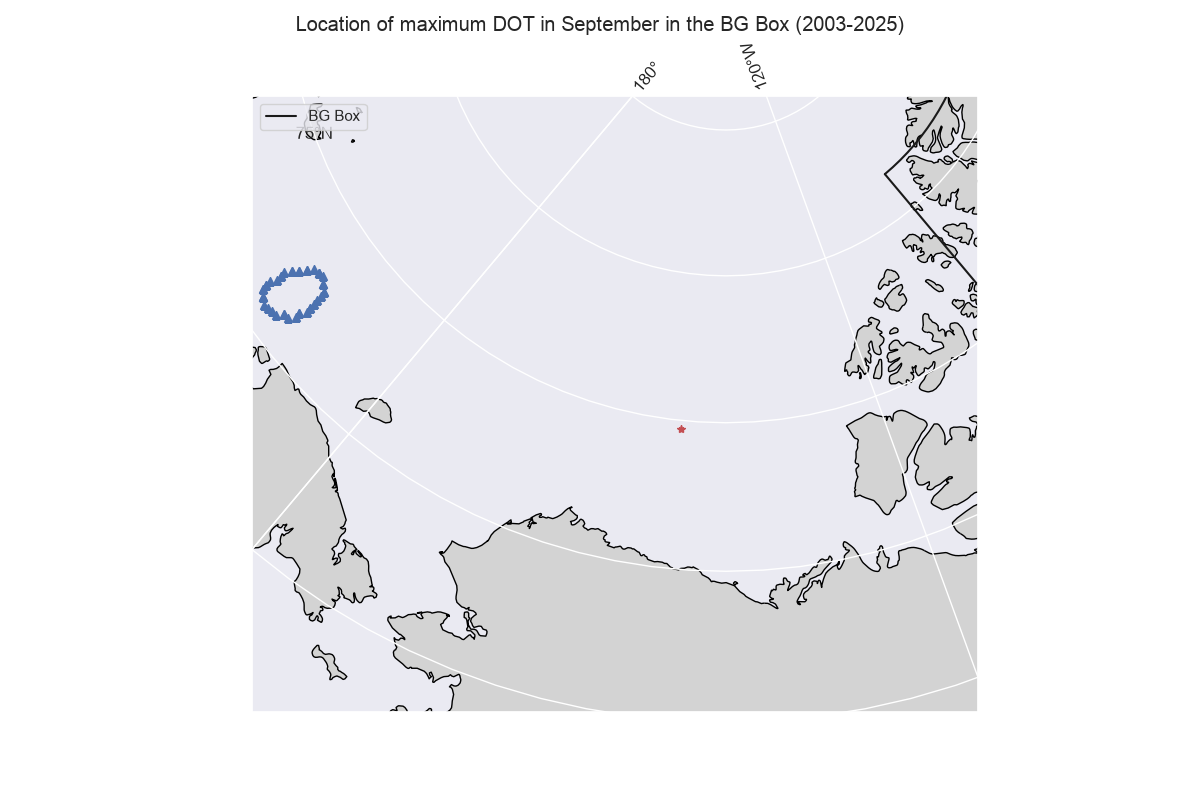

In [176]:
#Plot location of max DOT and min DOT contour
extent = [-180, -120, 65, 85]

dot_figure = plt.figure(figsize=(12,8))
projection=ccrs.NorthPolarStereo(central_longitude=-140)
ax = mapper.setup_map(figure=dot_figure,
                      projection=projection,
                      extent=extent)

sns.set_theme()





working_data = max_DOT_ds.where(max_DOT_ds['time'].dt.year == 2023)
ax.plot(working_data.sel(era = 'new')['lon'], working_data.sel(era = 'new')['lat'], marker = '*', color = 'r', transform = ccrs.PlateCarree())
    
ax.plot(closed_lon, closed_lat, 'b^', transform = ccrs.PlateCarree())

#Plot the Beaufort Gyre Box
top_bottom_lon= np.linspace(lon_min, lon_max, 100)
top_lat = np.full_like(top_bottom_lon, lat_max)
bottom_lat = np.full_like(top_bottom_lon, lat_min)
ax.plot([lon_min, lon_min], [lat_min, lat_max], 'k-', transform = ccrs.PlateCarree(), label = 'BG Box')
ax.plot([lon_max, lon_max], [lat_min, lat_max], 'k-', transform = ccrs.PlateCarree())
ax.plot(top_bottom_lon, top_lat, 'k-', transform = ccrs.PlateCarree())
ax.plot(top_bottom_lon, bottom_lat, 'k-', transform = ccrs.PlateCarree())

ax.legend()

dot_figure.suptitle("Location of maximum DOT in September in the BG Box (2003-2025)")


plt.show()